# P9 - Corrélation Quali / Quali
## Genre ↔ Catégories de produits

---

### 🎯 Objectif

Déterminer s'il existe un **lien statistique** entre le **genre des clients** (Homme/Femme) et les **catégories de produits** qu'ils achètent.

### 📚 Ce que vous allez apprendre

| Étape | Méthode | Outil |
|-------|---------|-------|
| Préparer | Tableau de contingence | `pd.crosstab()` |
| Visualiser | Heatmap | `plotly` / `seaborn` |
| Vérifier les conditions | Effectifs théoriques | Calcul manuel |
| Tester | Test du Chi² | `scipy.stats.chi2_contingency` |
| Interpréter | p-value, V de Cramer | Grille de lecture |

---

### ⚠️ Point important : Normalité et Chi²

Contrairement aux tests sur variables quantitatives (ANOVA, t-test), **le test du Chi² n'a pas de condition de normalité**.

| Type de corrélation | Test paramétrique | Condition | Alternative si non respectée |
|---------------------|-------------------|-----------|-----------------------------|
| Quanti / Quanti | Pearson | Normalité | Spearman |
| Quali / Quanti | ANOVA | Normalité | Kruskal-Wallis |
| **Quali / Quali** | **Chi²** | **Effectifs ≥ 5** | **Test exact de Fisher** |

Pour le Chi², la condition est que les **effectifs théoriques** soient suffisants (≥ 5 dans chaque case).

---

## 1. Configuration et chargement des données

In [1]:
# Import des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Bibliothèques statistiques
from scipy import stats
from scipy.stats import chi2_contingency

# Configuration
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Bibliothèques chargées avec succès !")

✅ Bibliothèques chargées avec succès !


In [48]:
# Charger les données préparées
DATA_PATH = "../data/processed/"

df = pd.read_csv(DATA_PATH + "transactions_enrichies.csv")
df['date'] = pd.to_datetime(df['date'])

print(f"✅ Données chargées : {len(df):,} transactions")
print(f"\nColonnes disponibles : {list(df.columns)}")

✅ Données chargées : 687,534 transactions

Colonnes disponibles : ['id_prod', 'date', 'session_id', 'client_id', 'price', 'categ', 'sex', 'birth', 'segment_client']


In [49]:
# Sélection des données pour analyse plus fiable / robuste

# Suppression des clients B2B
df = df[~df['segment_client'].isin(['B2B'])]
#df['segment_client'].value_counts()

# Conservation des clients uniques
df = df.drop_duplicates(subset=['client_id', 'categ'])
df.head()


,id_prod,date,session_id,client_id,price,categ,sex,birth,segment_client
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,11.99,0,f,1967,B2C
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,19.37,0,m,1960,B2C
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,4.50,0,m,1988,B2C
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,6.55,0,f,1989,B2C
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,16.49,0,f,1956,B2C


In [50]:
# Aperçu des variables qui nous intéressent
print("📊 VARIABLES ÉTUDIÉES")
print("=" * 40)
print(f"\n🔹 Genre (sex) :")
print(df['sex'].value_counts())
print(f"\n🔹 Catégories (categ) :")
print(df['categ'].value_counts())

📊 VARIABLES ÉTUDIÉES

🔹 Genre (sex) :
sex
f    10352
m     9588
Name: count, dtype: int64

🔹 Catégories (categ) :
categ
1    8455
0    7892
2    3593
Name: count, dtype: int64


---

## 2. Préparation : Tableau de contingence

### 📚 Qu'est-ce qu'un tableau de contingence ?

Un **tableau de contingence** (ou tableau croisé) compte les occurrences de chaque combinaison de modalités.

```
                 Catégorie A    Catégorie B    Catégorie C
Homme               150            200            180
Femme               120            250            160
```

C'est la base de l'analyse Chi².

In [51]:
# Créer le tableau de contingence
tableau_contingence = pd.crosstab(
    df['sex'],      # Lignes
    df['categ'],    # Colonnes
    margins=True,   # Ajouter les totaux
    margins_name='Total'
)

print("📊 TABLEAU DE CONTINGENCE : Genre × Catégories")
print("=" * 50)
display(tableau_contingence)

📊 TABLEAU DE CONTINGENCE : Genre × Catégories


categ,0,1,2,Total
sex,,,,
f,4119,4394,1839,10352
m,3773,4061,1754,9588
Total,7892,8455,3593,19940


In [ ]:
# Version en pourcentages (par ligne = par genre)
tableau_pct_ligne = pd.crosstab(
    df['sex'],
    df['categ'],
    normalize='index'  # Normaliser par ligne
) * 100

print("📊 TABLEAU EN POURCENTAGES (par genre)")
print("=" * 50)
print("Lecture : % des achats de chaque genre par catégorie\n")
display(tableau_pct_ligne.round(1))

📊 TABLEAU EN POURCENTAGES (par genre)
Lecture : % des achats de chaque genre par catégorie



categ,0,1,2
sex,,,
f,39.8,42.4,17.8
m,39.4,42.4,18.3


### 🤔 Première observation

En comparant les pourcentages :
- Si les % sont **similaires** entre Hommes et Femmes → probablement pas de lien
- Si les % sont **différents** → possible lien, à confirmer avec le test

---

## 3. Visualisation : Heatmap

Une **heatmap** permet de visualiser le tableau de contingence avec des couleurs.

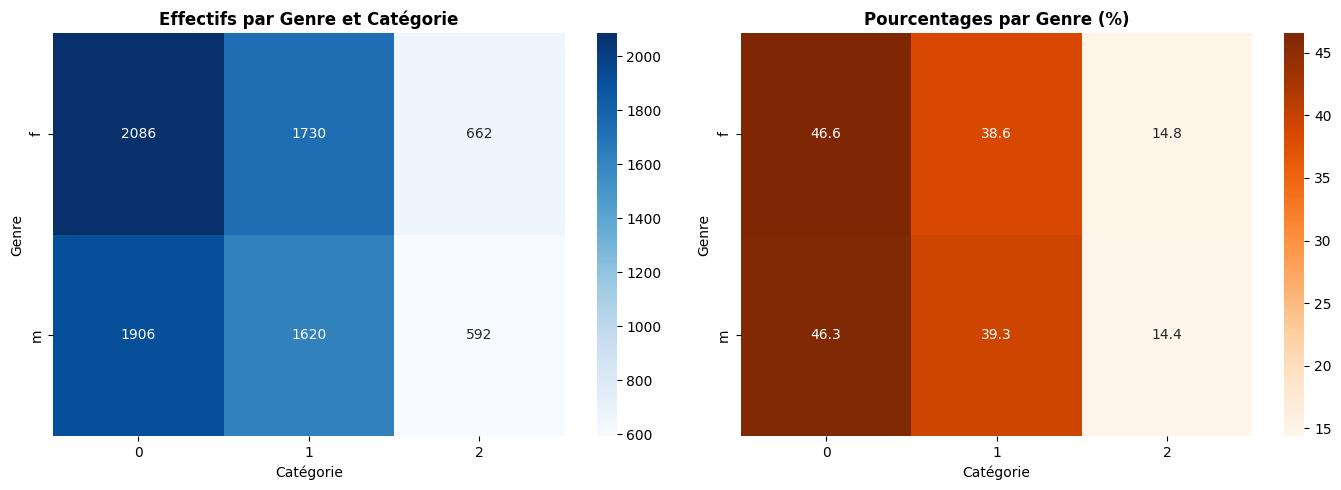

In [41]:
# Tableau sans les totaux pour la visualisation
tableau_sans_totaux = pd.crosstab(df['sex'], df['categ'])

# Heatmap avec Seaborn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap des effectifs
sns.heatmap(
    tableau_sans_totaux,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title('Effectifs par Genre et Catégorie', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Catégorie')
axes[0].set_ylabel('Genre')

# Heatmap des pourcentages
sns.heatmap(
    tableau_pct_ligne,
    annot=True,
    fmt='.1f',
    cmap='Oranges',
    ax=axes[1]
)
axes[1].set_title('Pourcentages par Genre (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Catégorie')
axes[1].set_ylabel('Genre')

plt.tight_layout()
plt.show()

In [7]:
# Version interactive avec Plotly
fig = px.imshow(
    tableau_pct_ligne.values,
    x=tableau_pct_ligne.columns.tolist(),
    y=tableau_pct_ligne.index.tolist(),
    color_continuous_scale='Blues',
    text_auto='.1f',
    title='Répartition des achats par Genre et Catégorie (%)',
    labels={'x': 'Catégorie', 'y': 'Genre', 'color': '%'}
)

fig.update_layout(
    template='plotly_white',
    height=400
)

fig.show()

In [53]:
# Graphique en barres groupées (alternative)
df_plot = tableau_pct_ligne.reset_index().melt(
    id_vars='sex',
    var_name='Catégorie',
    value_name='Pourcentage'
)

fig = px.bar(
    df_plot,
    x='Catégorie',
    y='Pourcentage',
    color='sex',
    barmode='group',
    title='Répartition des achats par Catégorie selon le Genre',
    labels={'sex': 'Genre', 'Pourcentage': 'Pourcentage (%)'},
    color_discrete_map={'f': '#E91E63', 'm': '#2196F3'}  # Rose pour F, Bleu pour M
)

fig.update_layout(template='plotly_white')
fig.show()

---

## 4. Vérification des conditions du Chi²

### 📚 Condition du test du Chi²

Le test du Chi² est valide si **tous les effectifs théoriques sont ≥ 5**.

### Qu'est-ce qu'un effectif théorique ?

C'est l'effectif qu'on **attendrait** dans chaque case **s'il n'y avait aucun lien** entre les variables.

$$\text{Effectif théorique} = \frac{\text{Total ligne} \times \text{Total colonne}}{\text{Total général}}$$

In [54]:
# Calculer les effectifs théoriques
# On utilise chi2_contingency qui les calcule automatiquement

chi2, p_value, dof, effectifs_theoriques = chi2_contingency(tableau_sans_totaux)

# Afficher les effectifs théoriques
df_theoriques = pd.DataFrame(
    effectifs_theoriques,
    index=tableau_sans_totaux.index,
    columns=tableau_sans_totaux.columns
)

print("📊 EFFECTIFS THÉORIQUES (attendus si pas de lien)")
print("=" * 50)
display(df_theoriques.round(1))

📊 EFFECTIFS THÉORIQUES (attendus si pas de lien)


categ,0,1,2
sex,,,
f,2079.6,1745.1,653.3
m,1912.4,1604.9,600.7


In [55]:
# Vérifier la condition : tous les effectifs théoriques ≥ 5 ?
print("🔍 VÉRIFICATION DE LA CONDITION DU CHI²")
print("=" * 50)
print(f"\nCondition : tous les effectifs théoriques doivent être ≥ 5")
print(f"\nEffectif théorique minimum : {effectifs_theoriques.min():.1f}")
print(f"Effectif théorique maximum : {effectifs_theoriques.max():.1f}")

# Compter les cases < 5
nb_cases_inf_5 = (effectifs_theoriques < 5).sum()

if nb_cases_inf_5 == 0:
    print(f"\n✅ CONDITION RESPECTÉE : toutes les cases ont un effectif théorique ≥ 5")
    print("   → Le test du Chi² est valide")
    condition_ok = True
else:
    print(f"\n⚠️  CONDITION NON RESPECTÉE : {nb_cases_inf_5} case(s) ont un effectif < 5")
    print("   → Il faudrait utiliser le test exact de Fisher")
    condition_ok = False

🔍 VÉRIFICATION DE LA CONDITION DU CHI²

Condition : tous les effectifs théoriques doivent être ≥ 5

Effectif théorique minimum : 600.7
Effectif théorique maximum : 2079.6

✅ CONDITION RESPECTÉE : toutes les cases ont un effectif théorique ≥ 5
   → Le test du Chi² est valide


### 📝 Que faire si la condition n'est pas respectée ?

| Situation | Solution |
|-----------|----------|
| Quelques cases < 5 | Regrouper des modalités |
| Beaucoup de cases < 5 | Utiliser le **test exact de Fisher** |
| Tableau 2×2 | Fisher est recommandé même si effectifs > 5 |

---

## 5. Test du Chi² (χ²)

### 📚 Principe du test

Le Chi² compare les **effectifs observés** (réels) aux **effectifs théoriques** (attendus si pas de lien).

- **H0 (hypothèse nulle)** : Il n'y a pas de lien entre Genre et Catégorie
- **H1 (hypothèse alternative)** : Il existe un lien entre Genre et Catégorie

$$\chi^2 = \sum \frac{(\text{Observé} - \text{Théorique})^2}{\text{Théorique}}$$

In [57]:
# Réaliser le test du Chi²
chi2, p_value, dof, expected = chi2_contingency(tableau_sans_totaux)

print("=" * 60)
print("📊 RÉSULTATS DU TEST DU CHI² (χ²)")
print("=" * 60)
print(f"\n🔹 Statistique Chi² : {chi2:.2f}")
print(f"🔹 Degrés de liberté : {dof}")
print(f"🔹 p-value : {p_value:.4f}")

📊 RÉSULTATS DU TEST DU CHI² (χ²)

🔹 Statistique Chi² : 0.56
🔹 Degrés de liberté : 2
🔹 p-value : 0.7558


In [58]:
# Interprétation automatique
seuil = 0.05  # Seuil de significativité classique

print("\n" + "=" * 60)
print("📋 INTERPRÉTATION")
print("=" * 60)
print(f"\nSeuil de significativité α = {seuil}")
print(f"p-value = {p_value:.4f}")

if p_value < seuil:
    print(f"\n✅ p-value < {seuil} → On REJETTE H0")
    print(f"\n📌 CONCLUSION : Il existe un lien SIGNIFICATIF entre le Genre et la Catégorie de produits.")
    print(f"   Les habitudes d'achat diffèrent selon le genre du client.")
    significatif = True
else:
    print(f"\n❌ p-value ≥ {seuil} → On NE PEUT PAS rejeter H0")
    print(f"\n📌 CONCLUSION : Pas de lien significatif détecté entre le Genre et la Catégorie.")
    print(f"   Les habitudes d'achat semblent similaires quel que soit le genre.")
    significatif = False


📋 INTERPRÉTATION

Seuil de significativité α = 0.05
p-value = 0.7558

❌ p-value ≥ 0.05 → On NE PEUT PAS rejeter H0

📌 CONCLUSION : Pas de lien significatif détecté entre le Genre et la Catégorie.
   Les habitudes d'achat semblent similaires quel que soit le genre.


---

## 6. Mesurer la force du lien : V de Cramer

### 📚 Pourquoi le V de Cramer ?

La p-value nous dit **s'il y a un lien**, mais pas **à quel point il est fort**.

Le **V de Cramer** mesure la force de l'association :
- Varie de **0** (aucun lien) à **1** (lien parfait)
- Indépendant de la taille de l'échantillon

In [59]:
def calculer_v_cramer(tableau):
    """
    Calcule le V de Cramer à partir d'un tableau de contingence.
    """
    chi2 = chi2_contingency(tableau)[0]
    n = tableau.sum().sum()  # Effectif total
    r, c = tableau.shape     # Nombre de lignes et colonnes
    
    # Formule du V de Cramer
    v = np.sqrt(chi2 / (n * (min(r, c) - 1)))
    
    return v

# Calculer le V de Cramer
v_cramer = calculer_v_cramer(tableau_sans_totaux)

print("=" * 60)
print("📊 FORCE DU LIEN : V DE CRAMER")
print("=" * 60)
print(f"\n🔹 V de Cramer : {v_cramer:.3f}")

📊 FORCE DU LIEN : V DE CRAMER

🔹 V de Cramer : 0.008


In [60]:
# Interprétation du V de Cramer
print("\n📋 INTERPRÉTATION DU V DE CRAMER")
print("-" * 40)

if v_cramer < 0.1:
    interpretation = "Lien NÉGLIGEABLE"
    symbole = "⚪"
elif v_cramer < 0.2:
    interpretation = "Lien FAIBLE"
    symbole = "🟡"
elif v_cramer < 0.3:
    interpretation = "Lien MODÉRÉ"
    symbole = "🟠"
else:
    interpretation = "Lien FORT"
    symbole = "🟢"

print(f"\n   {symbole} V = {v_cramer:.3f} → {interpretation}")

print("\n📚 Grille de lecture du V de Cramer :")
print("   ⚪ < 0.10 : Négligeable")
print("   🟡 0.10 - 0.20 : Faible")
print("   🟠 0.20 - 0.30 : Modéré")
print("   🟢 > 0.30 : Fort")


📋 INTERPRÉTATION DU V DE CRAMER
----------------------------------------

   ⚪ V = 0.008 → Lien NÉGLIGEABLE

📚 Grille de lecture du V de Cramer :
   ⚪ < 0.10 : Négligeable
   🟡 0.10 - 0.20 : Faible
   🟠 0.20 - 0.30 : Modéré
   🟢 > 0.30 : Fort


---

## 7. Synthèse complète

Voici une fonction qui réalise toute l'analyse en une fois.

In [61]:
def analyser_correlation_quali_quali(df, var1, var2, seuil=0.05):
    """
    Analyse complète de corrélation entre deux variables qualitatives.
    
    Paramètres:
    -----------
    df : DataFrame contenant les données
    var1 : nom de la première variable (lignes du tableau)
    var2 : nom de la deuxième variable (colonnes du tableau)
    seuil : seuil de significativité (défaut : 0.05)
    
    Retourne:
    ---------
    dict avec tous les résultats
    """
    
    print("=" * 70)
    print(f"📊 ANALYSE DE CORRÉLATION : {var1} ↔ {var2}")
    print("=" * 70)
    
    # 1. Tableau de contingence
    tableau = pd.crosstab(df[var1], df[var2])
    
    print("\n1️⃣  TABLEAU DE CONTINGENCE")
    print("-" * 40)
    display(tableau)
    
    # 2. Test du Chi²
    chi2, p_value, dof, expected = chi2_contingency(tableau)
    
    print("\n2️⃣  VÉRIFICATION DES CONDITIONS")
    print("-" * 40)
    effectif_min = expected.min()
    condition_ok = effectif_min >= 5
    
    print(f"   Effectif théorique minimum : {effectif_min:.1f}")
    if condition_ok:
        print("   ✅ Condition respectée (tous ≥ 5) → Chi² valide")
    else:
        print("   ⚠️  Condition NON respectée → Résultats à interpréter avec prudence")
    
    print("\n3️⃣  RÉSULTATS DU TEST DU CHI²")
    print("-" * 40)
    print(f"   Statistique χ² : {chi2:.2f}")
    print(f"   Degrés de liberté : {dof}")
    print(f"   p-value : {p_value:.4f}")
    
    # 3. V de Cramer
    n = tableau.sum().sum()
    r, c = tableau.shape
    v_cramer = np.sqrt(chi2 / (n * (min(r, c) - 1)))
    
    print(f"   V de Cramer : {v_cramer:.3f}")
    
    # 4. Interprétation
    print("\n4️⃣  CONCLUSION")
    print("-" * 40)
    
    # Significativité
    if p_value < seuil:
        print(f"   ✅ p-value ({p_value:.4f}) < seuil ({seuil})")
        print(f"   → Lien SIGNIFICATIF entre {var1} et {var2}")
        significatif = True
    else:
        print(f"   ❌ p-value ({p_value:.4f}) ≥ seuil ({seuil})")
        print(f"   → Pas de lien significatif entre {var1} et {var2}")
        significatif = False
    
    # Force du lien
    if v_cramer < 0.1:
        force = "négligeable"
    elif v_cramer < 0.2:
        force = "faible"
    elif v_cramer < 0.3:
        force = "modéré"
    else:
        force = "fort"
    
    print(f"   → Force du lien : {force} (V = {v_cramer:.3f})")
    
    print("\n" + "=" * 70)
    
    return {
        'chi2': chi2,
        'p_value': p_value,
        'dof': dof,
        'v_cramer': v_cramer,
        'significatif': significatif,
        'force': force,
        'condition_ok': condition_ok,
        'tableau': tableau
    }

In [16]:
# Utilisation de la fonction
resultats = analyser_correlation_quali_quali(df, 'sex', 'categ')

📊 ANALYSE DE CORRÉLATION : sex ↔ categ

1️⃣  TABLEAU DE CONTINGENCE
----------------------------------------


categ,0,1,2
sex,,,
f,206103,119307,17283
m,209356,116285,19200



2️⃣  VÉRIFICATION DES CONDITIONS
----------------------------------------
   Effectif théorique minimum : 18184.5
   ✅ Condition respectée (tous ≥ 5) → Chi² valide

3️⃣  RÉSULTATS DU TEST DU CHI²
----------------------------------------
   Statistique χ² : 158.25
   Degrés de liberté : 2
   p-value : 0.0000
   V de Cramer : 0.015

4️⃣  CONCLUSION
----------------------------------------
   ✅ p-value (0.0000) < seuil (0.05)
   → Lien SIGNIFICATIF entre sex et categ
   → Force du lien : négligeable (V = 0.015)



---

## 8. Récapitulatif pour le rapport 📝

Voici comment présenter ces résultats dans votre rapport ou présentation CODIR.

In [17]:
# Générer un texte de synthèse pour le rapport
print("="*70)
print("📄 TEXTE POUR LE RAPPORT / PRÉSENTATION")
print("="*70)

texte = f"""
ANALYSE DE CORRÉLATION : Genre des clients ↔ Catégories de produits

Méthodologie :
- Test utilisé : Chi² (χ²)
- Mesure de la force : V de Cramer
- Seuil de significativité : α = 0.05

Résultats :
- Statistique χ² = {resultats['chi2']:.2f}
- p-value = {resultats['p_value']:.4f}
- V de Cramer = {resultats['v_cramer']:.3f}

Conclusion :
"""

if resultats['significatif']:
    texte += f"""Il existe un lien statistiquement significatif entre le genre des clients 
et les catégories de produits achetés (p < 0.05). 
La force de ce lien est {resultats['force']} (V de Cramer = {resultats['v_cramer']:.3f}).

Recommandation : Adapter la stratégie marketing selon le genre des clients."""
else:
    texte += f"""Aucun lien statistiquement significatif n'a été détecté entre le genre 
des clients et les catégories de produits achetés (p ≥ 0.05).

Recommandation : Les actions marketing peuvent cibler tous les genres 
de la même manière pour chaque catégorie de produits."""

print(texte)

📄 TEXTE POUR LE RAPPORT / PRÉSENTATION

ANALYSE DE CORRÉLATION : Genre des clients ↔ Catégories de produits

Méthodologie :
- Test utilisé : Chi² (χ²)
- Mesure de la force : V de Cramer
- Seuil de significativité : α = 0.05

Résultats :
- Statistique χ² = 158.25
- p-value = 0.0000
- V de Cramer = 0.015

Conclusion :
Il existe un lien statistiquement significatif entre le genre des clients 
et les catégories de produits achetés (p < 0.05). 
La force de ce lien est négligeable (V de Cramer = 0.015).

Recommandation : Adapter la stratégie marketing selon le genre des clients.


---

## 9. Récapitulatif des apprentissages 📚

### Ce que vous avez appris

| Étape | Code clé | Ce que ça fait |
|-------|----------|----------------|
| Tableau de contingence | `pd.crosstab(var1, var2)` | Compte les combinaisons |
| Visualisation | `sns.heatmap()` ou `px.imshow()` | Heatmap colorée |
| Test Chi² | `chi2_contingency(tableau)` | Retourne χ², p-value, dof, effectifs théoriques |
| V de Cramer | Formule manuelle | Mesure la force du lien |

### Grilles d'interprétation

**p-value :**
| Valeur | Interprétation |
|--------|----------------|
| < 0.001 | Très significatif |
| < 0.01 | Significatif |
| < 0.05 | Significatif (seuil classique) |
| ≥ 0.05 | Non significatif |

**V de Cramer :**
| Valeur | Force du lien |
|--------|---------------|
| < 0.10 | Négligeable |
| 0.10 - 0.20 | Faible |
| 0.20 - 0.30 | Modéré |
| > 0.30 | Fort |

### Points clés à retenir

1. **Le Chi² n'a pas de condition de normalité** (contrairement à ANOVA)
2. **Condition du Chi²** : effectifs théoriques ≥ 5 dans chaque case
3. **Toujours visualiser** avant de tester (heatmap, barres groupées)
4. **p-value + V de Cramer** : la p-value dit si le lien existe, le V dit à quel point il est fort
5. **Un lien significatif mais faible** peut ne pas être utile en pratique